# Homework 08

# Data Exploration
### Selected equities : GOOGL and MSFT <br>

In [3]:
# lets load the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import quantstats as qs
import warnings
warnings.simplefilter(action="ignore", category=UserWarning)  # ignore warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)  # ignore runtime warnings
warnings.simplefilter(action="ignore", category=FutureWarning)  # ignore future warnings

# lets add the functions path to sys.path
import sys
sys.path.append('functions')

In [81]:
# We import 1-minute quotations for US stocks downloaded from Alpha Vantage
# for the period 2025-01-01 do 2025-09-30

# downloaded from the Internet
data_url = "http://coin.wne.uw.edu.pl/pwojcik/hfd/US_stocks.csv"

dataUSA = pd.read_csv(data_url, 
                      # try to parse column "timestamp" as dates/datetimes
                      parse_dates = ["timestamp"], 
                      # use column "timestamp" as dataframe index
                      index_col = "timestamp")

dataUSA.head()


,open_AAPL,high_AAPL,low_AAPL,close_AAPL,volume_AAPL,open_META,high_META,low_META,close_META,volume_META,...,open_MA,high_MA,low_MA,close_MA,volume_MA,open_V,high_V,low_V,close_V,volume_V
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-02 09:31:00,248.3506,248.4105,247.4327,247.6023,1245220,588.7706,591.9455,588.1616,591.9156,209802.0,...,526.1993,526.1993,523.6041,524.7426,48309.0,316.7216,316.9708,316.1435,316.8013,122361.0
2025-01-02 09:32:00,247.6672,248.5202,246.7044,247.0636,463134,591.7708,591.9905,589.9987,591.6660,36859.0,...,525.0856,525.1453,523.6538,523.6538,7293.0,316.9658,317.0405,316.0440,316.4724,17787.0
2025-01-02 09:33:00,246.9938,247.8218,246.6595,246.6845,219248,591.8657,592.5845,591.1892,592.0054,47969.0,...,524.1311,524.5686,523.2262,524.1012,8385.0,316.0439,316.4724,315.7748,316.1336,22212.0
2025-01-02 09:34:00,246.6546,246.7581,245.7966,246.2006,399303,591.9455,591.9455,589.5294,589.5491,53483.0,...,524.1112,524.1510,523.5693,523.8328,10321.0,316.1236,316.3827,315.8346,315.9542,14137.0
2025-01-02 09:35:00,246.1757,246.3652,245.7267,245.7567,289896,589.7690,590.2483,588.8207,588.9803,31812.0,...,523.8328,524.8371,523.8228,523.8974,10893.0,315.9442,316.9708,315.9442,316.5821,33400.0


In [5]:
dataUSA_close = dataUSA.filter(like = "close_")


In [ ]:
# Setting up return dataframe
dataUSA_r = np.log(dataUSA_close / dataUSA_close.shift(1)) * 10000
dataUSA_r.columns = [col.replace("close_", "r_") for col in dataUSA_r.columns]
dataUSA_r.columns

Index(['r_AAPL', 'r_META', 'r_GOOGL', 'r_KO', 'r_PEP', 'r_MSFT', 'r_GM',
       'r_GE', 'r_AMZN', 'r_TSLA', 'r_WMT', 'r_NVDA', 'r_MA', 'r_V'],
      dtype='object')

In [ ]:
# lets create an object with selected columns 
# only closing prices and rates of return for KO and PEP

dataUSA_GO_MS = pd.concat(
    [dataUSA_close[['close_GOOGL', 'close_MSFT']], 
     dataUSA_r[['r_GOOGL', 'r_MSFT']]],
    axis=1
)

dataUSA_GO_MS.head()

,close_GOOGL,close_MSFT,r_GOOGL,r_MSFT
timestamp,,,,
2025-01-02 09:31:00,190.3931,423.5085,NaN,NaN
2025-01-02 09:32:00,189.6449,424.2551,-39.375061,17.613405
2025-01-02 09:33:00,189.4254,422.8256,-11.580967,-33.751244
2025-01-02 09:34:00,188.6423,422.1233,-41.426502,-16.623494
2025-01-02 09:35:00,188.6373,422.1034,-0.265055,-0.471437


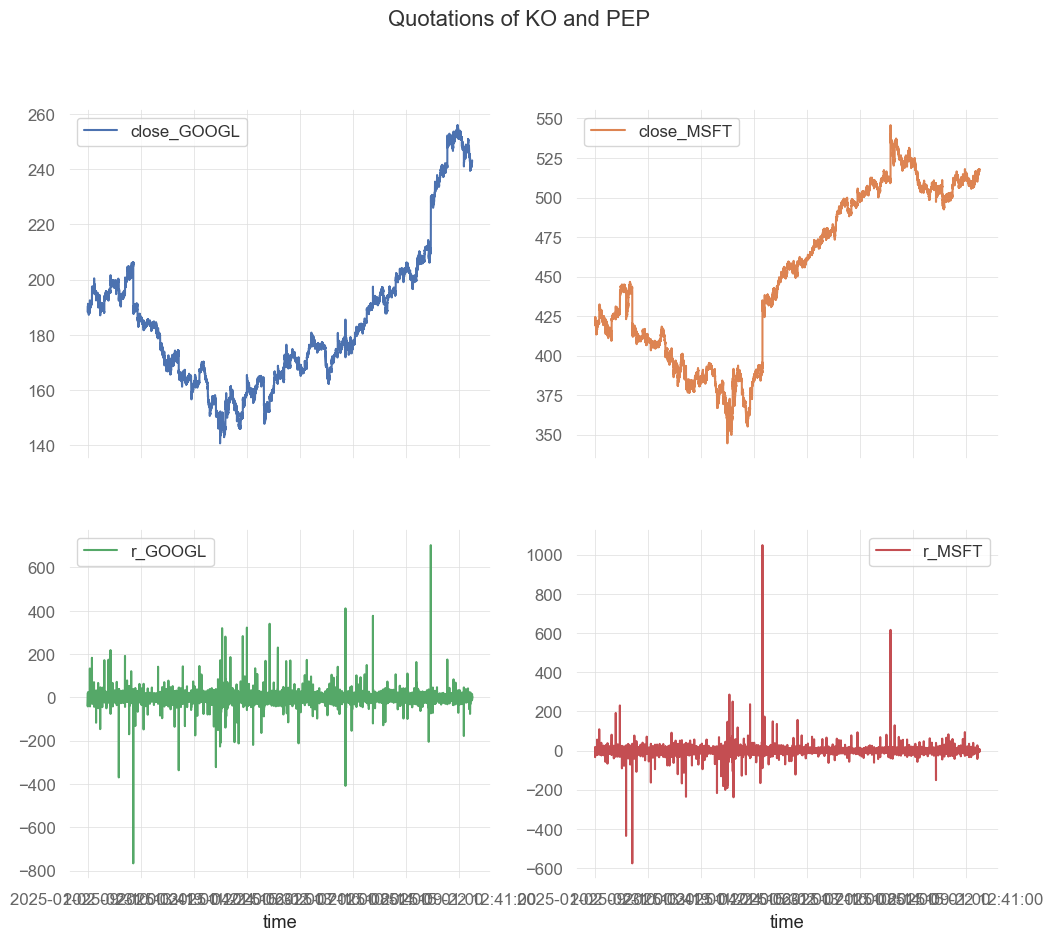

In [12]:
# Lets just make one copy for all plots
dataUSA_GO_MS_plot = dataUSA_GO_MS.copy()
dataUSA_GO_MS_plot['time'] = dataUSA_GO_MS_plot.index.astype(str)
# We reset the index to make 'time' a column
dataUSA_GO_MS_plot = dataUSA_GO_MS_plot.reset_index(drop = True)

# Let's set time as the X-axis and draw the graphs
dataUSA_GO_MS_plot.plot(
    x = 'time',
    subplots = True,
    layout = (2, 2),
    title = "Quotations of KO and PEP",
    figsize = (12, 10)
)
plt.show()

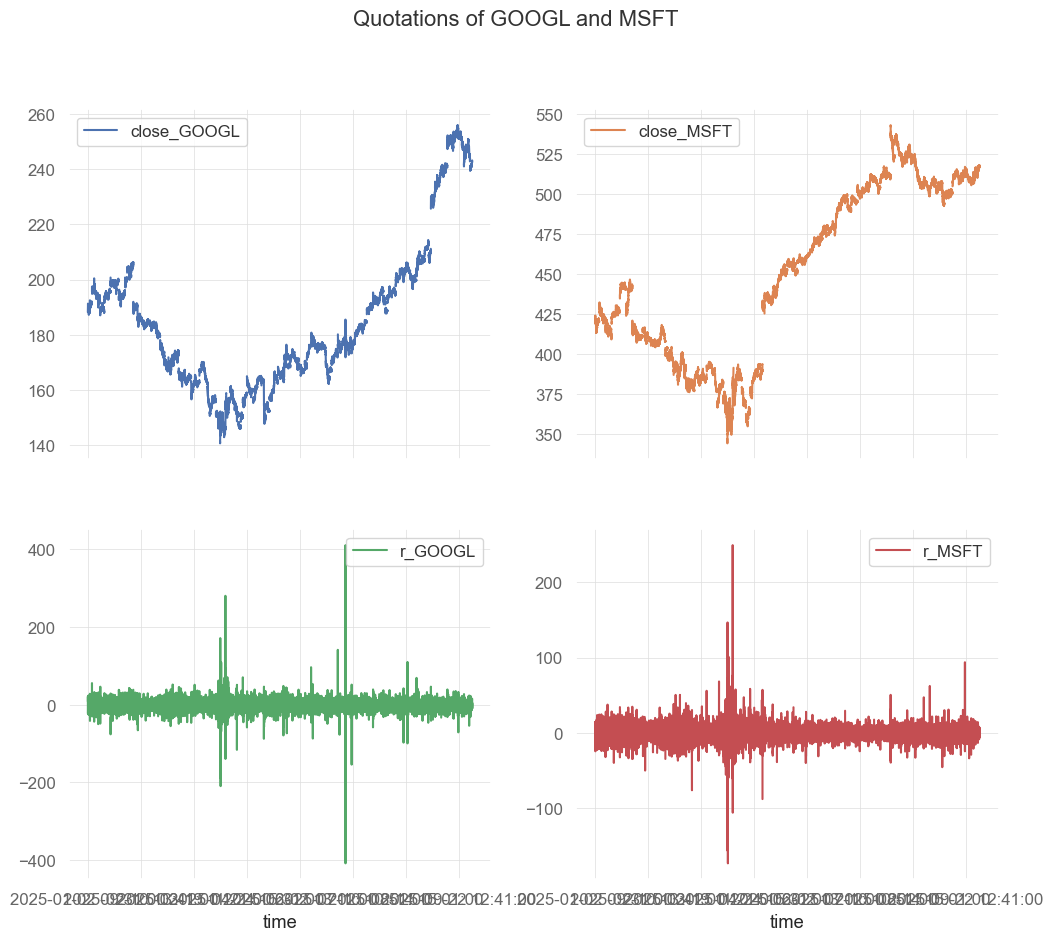

In [14]:
# initial assumptions about

# assumption 1
# we do not use the first 5 minutes of the session (9:31-9:35)
# and the last 5 minutes before the break (15:56-16:00) 
# let's insert missing data there

dataUSA_GO_MS.loc[dataUSA_GO_MS.between_time("9:31", "9:35").index] = np.nan
dataUSA_GO_MS.loc[dataUSA_GO_MS.between_time("15:56", "16:00").index] = np.nan

# and make the plots again

# Let's convert the datetime index to a text index and pass it as the x-axis
dataUSA_GO_MS_plot = dataUSA_GO_MS.copy()
dataUSA_GO_MS_plot['time'] = dataUSA_GO_MS_plot.index.astype(str)

# We reset the index to make 'time' a column
dataUSA_GO_MS_plot = dataUSA_GO_MS_plot.reset_index(drop = True)

# Let's set time as the X-axis and draw the graphs
dataUSA_GO_MS_plot.plot(
    x = 'time',
    subplots = True,
    layout = (2, 2),
    title = "Quotations of GOOGL and MSFT ",
    figsize = (12, 10)
)
plt.show()


## Spread 1 based on prices

lets formulate a spread: `P1 - m * P2` (here `P_KO - m * P_PEP`)

where `m = m1/m2` is based on average ratio between the prices on the **PREVIOUS** day

Spread is a signal to our model, which shows whether to take position or not (volatility bands around the spread).

**CAUTION**! we assume the mean reverting behavior of the spread! 

We will calculate `m` based on **previous day's average prices**


## Plot av ratio

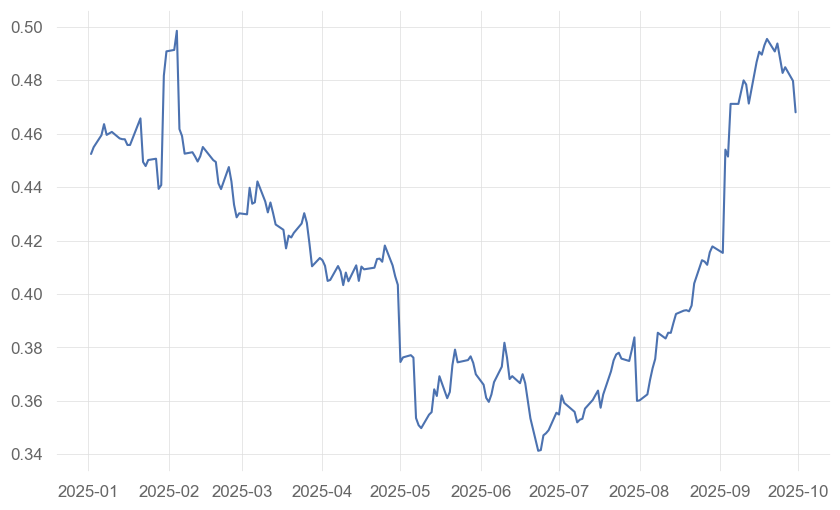

In [16]:
# lets calculate average ratio of prices on the daily basis

# Compute the ratio close_GOOGL / close_MSFT
ratio = dataUSA_GO_MS["close_GOOGL"] / dataUSA_GO_MS["close_MSFT"]

# Compute daily averages
US_av_ratio = ratio.resample("D").mean()
# keep non-missing values only
US_av_ratio = US_av_ratio.dropna()

# Assign the name
US_av_ratio = US_av_ratio.to_frame(name="av_ratio")

# Plot how the average ratio looks like
plt.plot(US_av_ratio.index, 
         US_av_ratio["av_ratio"])

# between 0.42 and 0.56


But calculations based on the first day will be used on the second day, etc.

Lets adjust the dataset accordingly by moving the time index to 9:30 of the next (trading) day.

In [17]:
# lets apply the changes in our data object
US_av_ratio.index = US_av_ratio.index + pd.to_timedelta(np.where(US_av_ratio.index.day_name() == "Friday", "3D", "1D")) + pd.Timedelta("9h31m")

US_av_ratio.head()

,av_ratio
2025-01-03 09:31:00,0.452404
2025-01-06 09:31:00,0.454940
2025-01-07 09:31:00,0.459433
2025-01-08 09:31:00,0.463573
2025-01-09 09:31:00,0.459539


## Spread 2 based on returns

alternative spread based on **RETURNS**:

`r1 - ms * r2` (here `r_KO - m * r_PEP`)

where `ms = s1/s2` is based on the ratio of **standard deviations** of returns on the **PREVIOUS** day

In [18]:
dataUSA_GO_MS.columns

Index(['close_GOOGL', 'close_MSFT', 'r_GOOGL', 'r_MSFT'], dtype='object')

## Plot SDS ratio. 
Standard Deviation of Spread

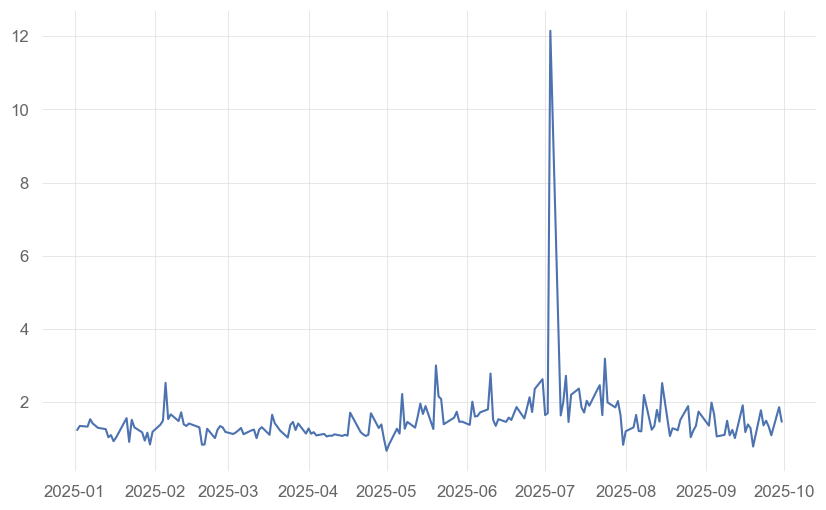

In [20]:
# Daily standard deviation ratio
US_sds_ratio = (
    dataUSA_GO_MS
    .resample("D")
    .apply(lambda x: x["r_GOOGL"].std() / x["r_MSFT"].std())
    .to_frame(name = "sds_ratio")
)

# keep non-missing values only
US_sds_ratio = US_sds_ratio.dropna()

# see how it changes over time
plt.plot(US_sds_ratio.index, 
         US_sds_ratio["sds_ratio"])


In [21]:
# lets move the index to 9:31 of the next trading day
US_sds_ratio.index = US_sds_ratio.index + pd.to_timedelta(np.where(US_sds_ratio.index.day_name() == "Friday", "3D", "1D")) + pd.Timedelta("9h31m")

In [ ]:
# we need to merge our basic 1 min data with daily calculations
dataUSA_2 = dataUSA_GO_MS.copy()
dataUSA_2 = dataUSA_2.merge(US_av_ratio, 
                            left_index = True, 
                            right_index = True, 
                            how = "left")
dataUSA_2 = dataUSA_2.merge(US_sds_ratio,
                            left_index = True, 
                            right_index = True, 
                            how = "left")

# lets see how it worked
dataUSA_2.between_time("09:31", "09:40").head(1)

# there are a lot of missings in a the last 2 columns
# which should be filled with the last non-missing value
# (last multiplier is used until there is a new one)

,close_GOOGL,close_MSFT,r_GOOGL,r_MSFT,av_ratio,sds_ratio
timestamp,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# We apply forward fill method to the last two columns
dataUSA_2[["av_ratio", "sds_ratio"]] = dataUSA_2[["av_ratio", "sds_ratio"]].ffill()

# and check the results
dataUSA_2.between_time("09:31", "09:40").head(1)

# now the values are filled properly

,close_GOOGL,close_MSFT,r_GOOGL,r_MSFT,av_ratio,sds_ratio
timestamp,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN


## Spread calculation

In [82]:
# calculate spread in two strategies
dataUSA_2["spread_avratio"] = dataUSA_2["close_GOOGL"] - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"]
dataUSA_2["spread_sdsratio"] = dataUSA_2["r_GOOGL"] - dataUSA_2["sds_ratio"] * dataUSA_2["close_MSFT"]

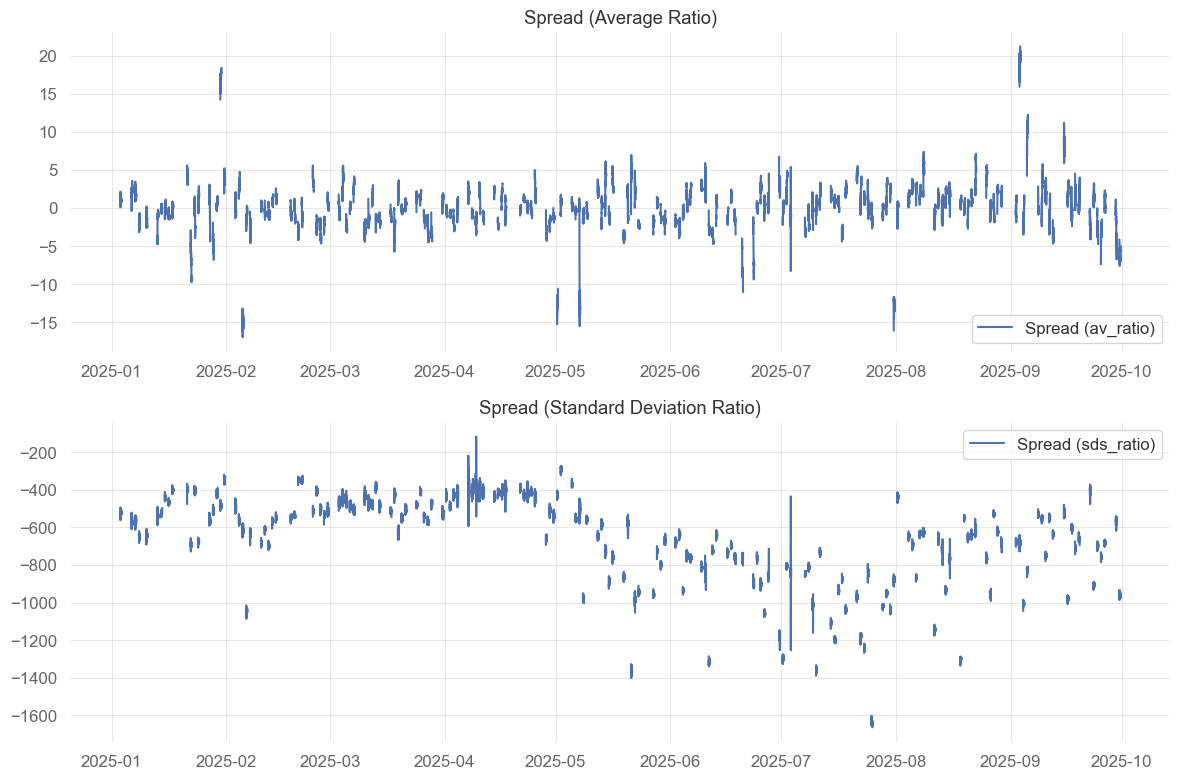

In [26]:
# plot both spreads in separate subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

axes[0].plot(dataUSA_2.index, 
             dataUSA_2["spread_avratio"], 
             label = "Spread (av_ratio)")
axes[0].set_title("Spread (Average Ratio)")
axes[0].legend()

axes[1].plot(dataUSA_2.index, 
             dataUSA_2["spread_sdsratio"], 
             label = "Spread (sds_ratio)")
axes[1].set_title("Spread (Standard Deviation Ratio)")
axes[1].legend()

plt.tight_layout()
plt.show()


# Applying volatility breakout model. 
Using initial guess for params. i.e 120 for rolling window and m = 3

In [52]:
# standard deviation of the spreads 
# applying the volatility breakout model
# usingrolling window of 120 minutes (2 hours)

dataUSA_2["std_spread_avratio"] = dataUSA_2["spread_avratio"].rolling(window=120).std()
dataUSA_2["std_spread_sdsratio"] = dataUSA_2["spread_sdsratio"].rolling(window=120).std()

dataUSA_2.loc[dataUSA_2["close_GOOGL"].isna(), ["std_spread_avratio", "std_spread_sdsratio"]] = np.nan

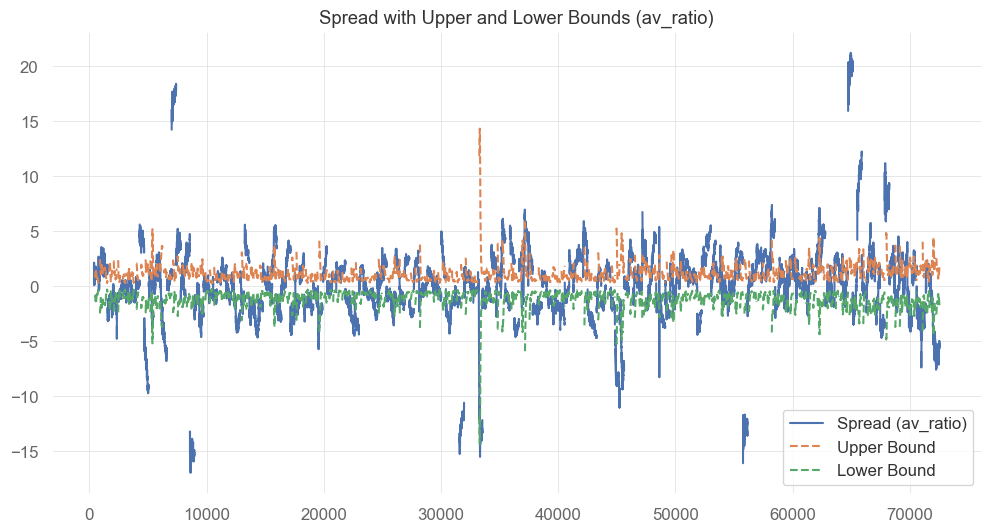

In [ ]:
# applying a volatility breakout model
# sample upper and lower bounds for spreads
# for a volatility multiplier of 3
# (here we put the upper and lower band along zero)

dataUSA_2["upper_bound_avratio"] = 3 * dataUSA_2["std_spread_avratio"]
dataUSA_2["lower_bound_avratio"] = -3 * dataUSA_2["std_spread_avratio"]

dataUSA_2_plot = dataUSA_2.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["spread_avratio"], 
         label="Spread (av_ratio)")
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["upper_bound_avratio"], 
         label="Upper Bound", linestyle='--')
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["lower_bound_avratio"], 
         label="Lower Bound", linestyle='--')
plt.title("Spread with Upper and Lower Bounds (av_ratio)")
plt.legend()
plt.show()  

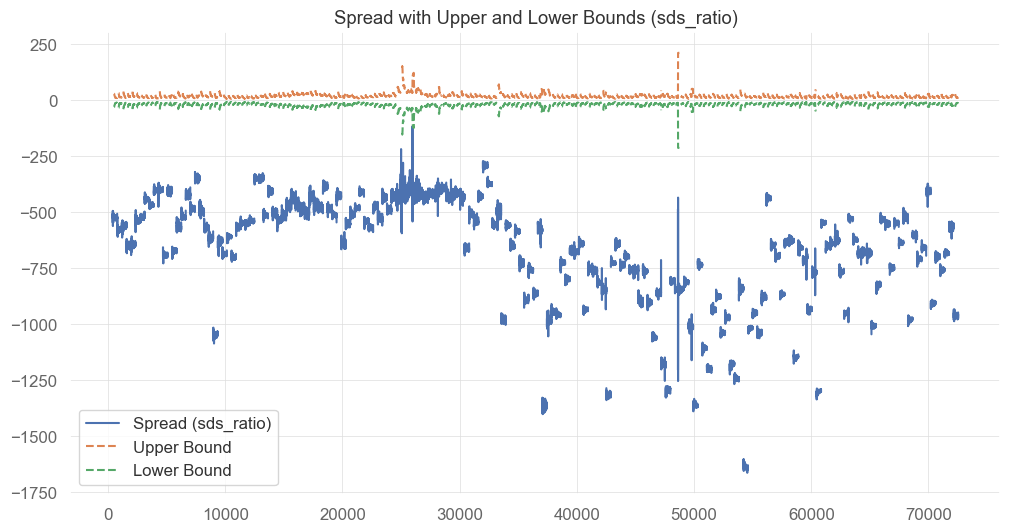

In [30]:
# the same for spread_sdsratio

dataUSA_2["upper_bound_sdsratio"] = 3 * dataUSA_2["std_spread_sdsratio"]
dataUSA_2["lower_bound_sdsratio"] = -3 * dataUSA_2["std_spread_sdsratio"]

# lets see how it looks like
# ignoring time dimension for clarity
dataUSA_2_plot = dataUSA_2.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["spread_sdsratio"], 
         label="Spread (sds_ratio)")
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["upper_bound_sdsratio"],
         label="Upper Bound", linestyle='--')
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["lower_bound_sdsratio"],
         label="Lower Bound", linestyle='--')
plt.title("Spread with Upper and Lower Bounds (sds_ratio)")
plt.legend()
plt.show()

In [31]:
### position will be based on relation of the spread to volatility bands

# lets assume we do not trade within the first 15-mins of the day
# and exit all positions 15 minutes before the end of quotations

# lets create a pos_flat vector and fill it with 0s

pos_flat = np.zeros(len(dataUSA_2))

In [32]:
# we do not trade within the first quarter (9:31-9:45) 
# but also before that time since midnight

pos_flat[dataUSA_2.index.time <= pd.to_datetime("9:45").time()] = 1

# and last quarter of the session (15:46-16:00)
# but also after this time until midnight

pos_flat[dataUSA_2.index.time >= pd.to_datetime("15:46").time()] = 1

# !!! there are no weekends in our data, so we do not need 
# to control for that in pos_flat

pd.Series(pos_flat).value_counts()

0.0    66960
1.0     5580
Name: count, dtype: int64

In [33]:
# lets use the positionVB() function known from previous labs
# to calculate the position based on spread_avratio

from functions.position_VB import positionVB

dataUSA_2["pos_avratio"] = positionVB(signal = dataUSA_2["spread_avratio"],
                                      lower = dataUSA_2["lower_bound_avratio"],
                                      upper = dataUSA_2["upper_bound_avratio"],
                                      pos_flat = pos_flat,
                                      # IMPORTANT !!!!
                                      strategy = "mr")

dataUSA_2["pos_avratio"].value_counts()

pos_avratio
 0.0    32840
-1.0    20480
 1.0    19220
Name: count, dtype: int64

### Gross and net pnl

In [ ]:
# lets create a vector of the number of transactions
dataUSA_2["n_trans_avratio"] = np.abs(np.diff(dataUSA_2["pos_avratio"], prepend = 0))

In [35]:
# next we calculate the gross P&L from the strategy
# for every minute 
# we multiply the position by the return of the spread

# gross PnL = position * (dP_GOOGL - ratio * dP_MSFT) 

dataUSA_2["pnl_gross_avratio"] = dataUSA_2["pos_avratio"] * (dataUSA_2["close_GOOGL"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"].diff())


In [36]:
# Lets assume the trading cost on the level of 5 bpts (0.05%) per transaction

# check its value based on average closing prices
# during the analysed period

trcost_GOOGL = round(dataUSA_close["close_GOOGL"].mean() * 0.0005, 2)
trcost_MSFT = round(dataUSA_close["close_MSFT"].mean() * 0.0005, 2)

print(f"Trading cost per transaction for KO: {trcost_GOOGL:.2f} USD")
print(f"Trading cost per transaction for PEP: {trcost_MSFT:.2f} USD")

Trading cost per transaction for KO: 0.09 USD
Trading cost per transaction for PEP: 0.23 USD


In [37]:
# pnl after  costs

# !!! REMEMBER that we trade one unit of GOOGL and av_ratio units of MSFT
# AND there is NO minus "-" in the costs - they are always positive !!!

dataUSA_2["pnl_net_avratio"] = dataUSA_2["pnl_gross_avratio"] - dataUSA_2["n_trans_avratio"] * (trcost_GOOGL + dataUSA_2["av_ratio"] * trcost_MSFT)


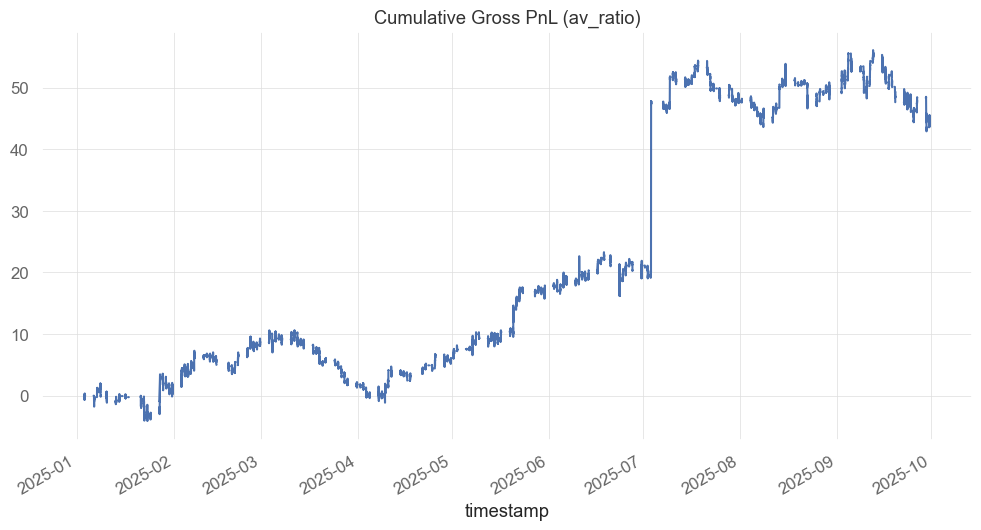

In [ ]:
# lets calculate and plot cumulative gross PnL
# without adding a new column to the data

dataUSA_2["pnl_gross_avratio"].cumsum().plot(figsize=(12,6), 
                                             title="Cumulative Gross PnL (av_ratio)")
plt.show()

# positive, but not very impressive...

# Cumulative net PnL

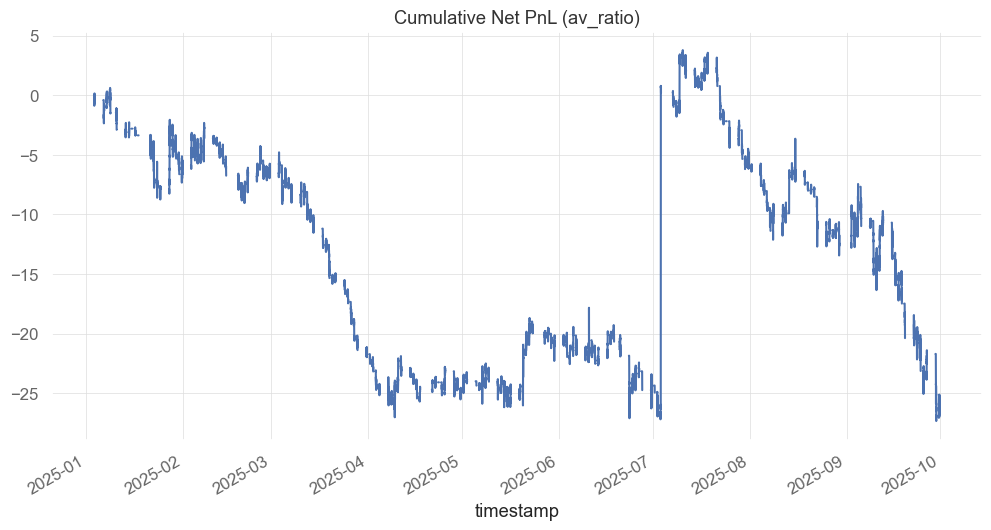

In [ ]:
# cummulative net PnL?

dataUSA_2["pnl_net_avratio"].cumsum().plot(figsize=(12,6), 
                                           title="Cumulative Net PnL (av_ratio)")
plt.show()


# Choosing best in terms of SR Ratio

In [ ]:
# Comparison within a loop for spread_avratio and spread_sdsratio

def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

volat_sd_parameters = [60, 90, 120, 150, 180]
m_parameters = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]

# create a dataframe to store results
summary_all_GO_MS = pd.DataFrame()

for volat_sd in volat_sd_parameters:
    for m in m_parameters:
        print(f"volat_sd: {volat_sd}, m: {m}")

        # calculate teh elements of the strategy
        close_GO = dataUSA_2["close_GOOGL"]
        close_MS = dataUSA_2["close_MSFT"]

        # spread based on average ratio
        signal_avratio = close_GO - (dataUSA_2["av_ratio"] * close_MS)
        std_spread_avratio = signal_avratio.rolling(window=volat_sd).std()
        upper_bound_avratio = m * std_spread_avratio
        lower_bound_avratio = -m * std_spread_avratio
        # position
        pos_avratio = positionVB(signal = signal_avratio,
                                lower = lower_bound_avratio,
                                upper = upper_bound_avratio,
                                pos_flat = pos_flat,
                                strategy = "mr")
        # number of transactions
        n_trans_avratio = np.abs(np.diff(pos_avratio, prepend = 0))
        # convert to pd.Series and set the index
        n_trans_avratio = pd.Series(n_trans_avratio, index=dataUSA_2.index)

        # gross and net PnL
        pnl_gross_avratio = pos_avratio * (dataUSA_2["close_GOOGL"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"].diff())
        pnl_net_avratio = pnl_gross_avratio - n_trans_avratio * (trcost_GOOGL + dataUSA_2["av_ratio"] * trcost_MSFT)

        # spread based on standard deviation ratio
        signal_sdsratio = dataUSA_2["spread_sdsratio"]
        std_spread_sdsratio = signal_sdsratio.rolling(window=volat_sd).std()
        upper_bound_sdsratio = m * std_spread_sdsratio
        lower_bound_sdsratio = -m * std_spread_sdsratio
        # position
        pos_sdsratio = positionVB(signal = signal_sdsratio,
                                lower = lower_bound_sdsratio,
                                upper = upper_bound_sdsratio,
                                pos_flat = pos_flat,
                                strategy = "mr")
        
        # number of transactions
        n_trans_sdsratio = np.abs(np.diff(pos_sdsratio, prepend = 0))
        # convert to pd.Series and set the index
        n_trans_sdsratio = pd.Series(n_trans_sdsratio, index=dataUSA_2.index)

        # !!!!! signal is based on returns, but PnL on prices !!!!
        pnl_gross_sdsratio = pos_sdsratio * (dataUSA_2["close_GOOGL"].diff() - dataUSA_2["sds_ratio"] * dataUSA_2["close_MSFT"].diff())
        pnl_net_sdsratio = pnl_gross_sdsratio - n_trans_sdsratio * (trcost_GOOGL + dataUSA_2["sds_ratio"] * trcost_MSFT)

        # aggregate to daily
        pnl_gross_avratio_daily = pnl_gross_avratio.resample("D").sum().dropna()
        pnl_gross_sdsratio_daily = pnl_gross_sdsratio.resample("D").sum().dropna()
        pnl_net_avratio_daily = pnl_net_avratio.resample("D").sum().dropna()
        pnl_net_sdsratio_daily = pnl_net_sdsratio.resample("D").sum().dropna()
        n_trans_avratio_daily = n_trans_avratio.resample("D").sum().dropna()
        n_trans_sdsratio_daily = n_trans_sdsratio.resample("D").sum().dropna()

        # calculate summary measures
        gross_SR_avratio = mySR(pnl_gross_avratio_daily, scale = 252)
        net_SR_avratio = mySR(pnl_net_avratio_daily, scale = 252)
        gross_PnL_avratio = pnl_gross_avratio_daily.sum()
        net_PnL_avratio = pnl_net_avratio_daily.sum()
        av_daily_ntrans_avratio = n_trans_avratio_daily.mean()
        
        gross_SR_sdsratio = mySR(pnl_gross_sdsratio_daily, scale = 252)
        net_SR_sdsratio = mySR(pnl_net_sdsratio_daily, scale = 252)
        gross_PnL_sdsratio = pnl_gross_sdsratio_daily.sum()
        net_PnL_sdsratio = pnl_net_sdsratio_daily.sum()
        av_daily_ntrans_sdsratio = n_trans_sdsratio_daily.mean()
        
        # Collect the necessary results into one object
        summary = pd.DataFrame({
                'volat_sd': volat_sd,
                'm': m,
                'period': '2025Q1-Q3',
                'gross_SR_avratio': gross_SR_avratio,
                'net_SR_avratio': net_SR_avratio,
                'gross_PnL_avratio': gross_PnL_avratio,
                'net_PnL_avratio': net_PnL_avratio,
                'av_daily_ntrans_avratio': av_daily_ntrans_avratio,
                'gross_SR_sdsratio': gross_SR_sdsratio,
                'net_SR_sdsratio': net_SR_sdsratio,
                'gross_PnL_sdsratio': gross_PnL_sdsratio,
                'net_PnL_sdsratio': net_PnL_sdsratio,
                'av_daily_ntrans_sdsratio': av_daily_ntrans_sdsratio
                }, index=[0])

        # Append the results to the summary
        summary_all_GO_MS = pd.concat([summary_all_GO_MS, 
                                        summary], 
                                    ignore_index = True)

# it takes about 3 minutes to run

volat_sd: 60, m: 0.5
volat_sd: 60, m: 1
volat_sd: 60, m: 1.5
volat_sd: 60, m: 2
volat_sd: 60, m: 2.5
volat_sd: 60, m: 3
volat_sd: 60, m: 3.5
volat_sd: 90, m: 0.5
volat_sd: 90, m: 1
volat_sd: 90, m: 1.5
volat_sd: 90, m: 2
volat_sd: 90, m: 2.5
volat_sd: 90, m: 3
volat_sd: 90, m: 3.5
volat_sd: 120, m: 0.5
volat_sd: 120, m: 1
volat_sd: 120, m: 1.5
volat_sd: 120, m: 2
volat_sd: 120, m: 2.5
volat_sd: 120, m: 3
volat_sd: 120, m: 3.5
volat_sd: 150, m: 0.5
volat_sd: 150, m: 1
volat_sd: 150, m: 1.5
volat_sd: 150, m: 2
volat_sd: 150, m: 2.5
volat_sd: 150, m: 3
volat_sd: 150, m: 3.5
volat_sd: 180, m: 0.5
volat_sd: 180, m: 1
volat_sd: 180, m: 1.5
volat_sd: 180, m: 2
volat_sd: 180, m: 2.5
volat_sd: 180, m: 3
volat_sd: 180, m: 3.5


## Best Gross SR for spread av_ratio

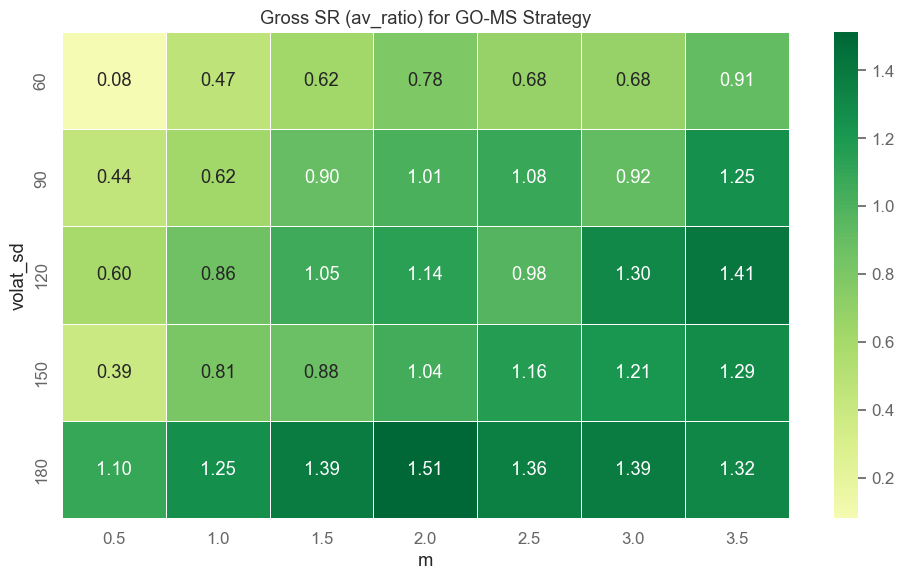

In [ ]:
from functions.plot_heatmap import plot_heatmap
# gross SR - spread av_ratio
plot_heatmap(summary_all_GO_MS, 
             value_col = "gross_SR_avratio", 
             index_col = "volat_sd", 
             columns_col = "m", 
             title = "Gross SR (av_ratio) for GO-MS Strategy")

## Best Net SR for spread av_ratio

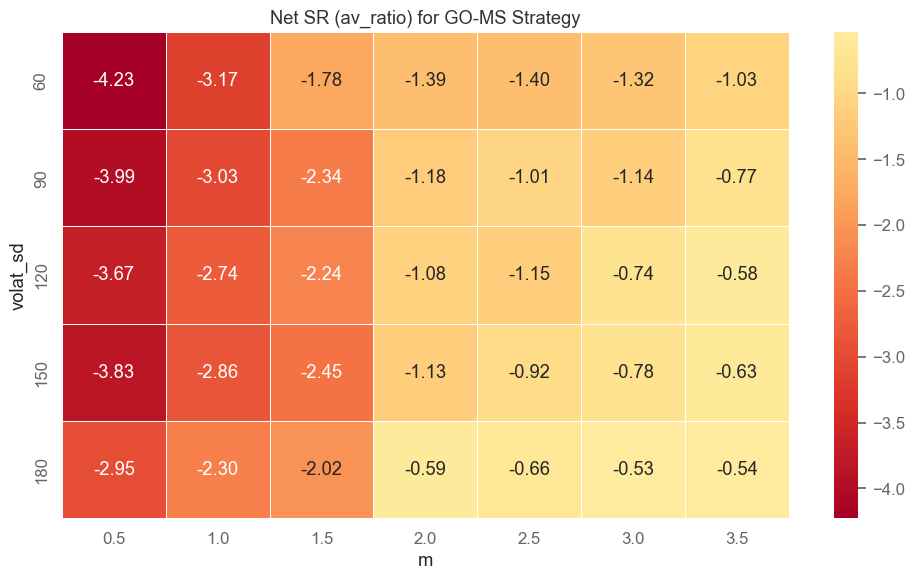

In [46]:
# net SR - spread av_ratio
plot_heatmap(summary_all_GO_MS,
             value_col = "net_SR_avratio", 
             index_col = "volat_sd", 
             columns_col = "m", 
             title = "Net SR (av_ratio) for GO-MS Strategy")

# Exercise 8.1

* using `plot_heatmap()` function check profitability of strategies using spread_sdsratio
* for the best combination of parameters (in terms of net SR) prepare and plot the equity curve (gross and net cummulatve pnl)

# Exercise 8.2

build and test a similar model for another pair of stocks (play with different parameter values and spread definition) - assume costs at the level of 5 bps


# Main Params and optimal as per highest sharpee<br>
- volat_sd = rolling window size (number of past points) to estimate sigma . Optimal : 180 for gross and net<br>
- m = how many sigma you set the entry/exit bands away from 0. Optimal : 2 for gross and 3 for net<br>

In [67]:
# now we can calculate the spread (in 2 variants)
dataUSA_2["spread_avratio"] = dataUSA_2["close_GOOGL"] - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"]
dataUSA_2["spread_sdsratio"] = dataUSA_2["r_GOOGL"] - dataUSA_2["sds_ratio"] * dataUSA_2["r_MSFT"]

In [68]:
dataUSA_2["std_spread_avratio"] = dataUSA_2["spread_avratio"].rolling(window=180).std()
dataUSA_2["std_spread_sdsratio"] = dataUSA_2["spread_sdsratio"].rolling(window=180).std()


## Position for avratio

In [69]:
from functions.position_VB import positionVB
dataUSA_2["upper_bound_avratio"] = 2 * dataUSA_2["std_spread_avratio"]
dataUSA_2["lower_bound_avratio"] = -2 * dataUSA_2["std_spread_avratio"]

dataUSA_2["pos_avratio"] = positionVB(signal = dataUSA_2["spread_avratio"],
                                      lower = dataUSA_2["lower_bound_avratio"],
                                      upper = dataUSA_2["upper_bound_avratio"],
                                      pos_flat = pos_flat,
                                      strategy = "mr")

dataUSA_2["pos_avratio"].value_counts()

pos_avratio
 0.0    40955
-1.0    15952
 1.0    15633
Name: count, dtype: int64

## Position for sdsratio

In [70]:
from functions.position_VB import positionVB
dataUSA_2["upper_bound_sdsratio"] = 2 * dataUSA_2["std_spread_sdsratio"]
dataUSA_2["lower_bound_sdsratio"] = -2 * dataUSA_2["std_spread_sdsratio"]

dataUSA_2["pos_sdsratio"] = positionVB(signal = dataUSA_2["spread_sdsratio"],
                                      lower = dataUSA_2["lower_bound_sdsratio"],
                                      upper = dataUSA_2["upper_bound_sdsratio"],
                                      pos_flat = pos_flat,
                                      # IMPORTANT !!!!
                                      strategy = "mr")

dataUSA_2["pos_sdsratio"].value_counts()

pos_sdsratio
 0.0    50794
-1.0    10879
 1.0    10867
Name: count, dtype: int64

# Cummulative Gross PnL (avratio)

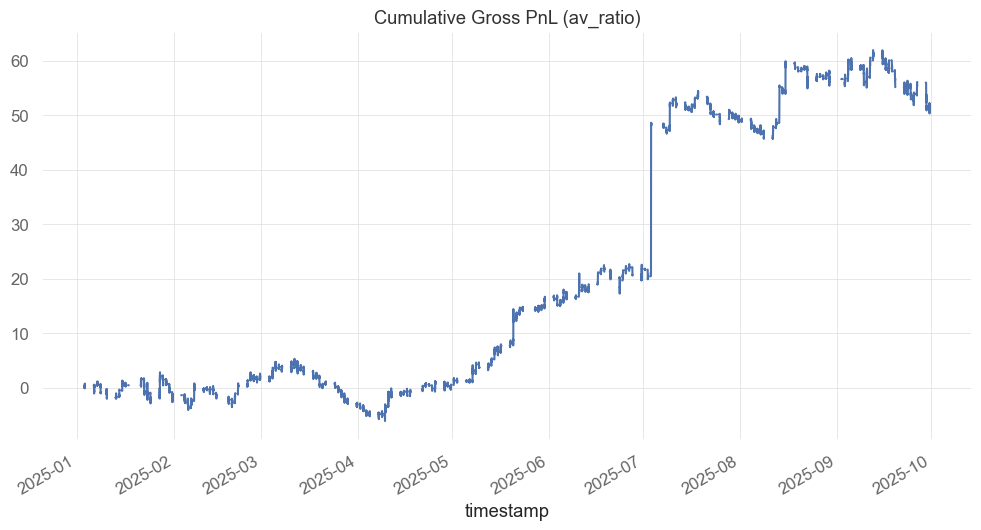

In [78]:

trcost_GOOGL = round(dataUSA_close["close_GOOGL"].mean() * 0.0005, 2) #### transaction costs at 5bp
trcost_MSFT = round(dataUSA_close["close_MSFT"].mean() * 0.0005, 2)

dataUSA_2["pnl_gross_avratio"] = dataUSA_2["pos_avratio"] * (dataUSA_2["close_GOOGL"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"].diff())
dataUSA_2["n_trans_avratio"] = np.abs(np.diff(dataUSA_2["pos_avratio"], prepend = 0))
dataUSA_2["pnl_net_avratio"] = dataUSA_2["pnl_gross_avratio"] - dataUSA_2["n_trans_avratio"] * (trcost_GOOGL + dataUSA_2["av_ratio"] * trcost_MSFT)



dataUSA_2["pnl_gross_avratio"].cumsum().plot(figsize=(12,6), 
                                             title="Cumulative Gross PnL (av_ratio)")
plt.show()

# Cummulative net PnL (avratio)

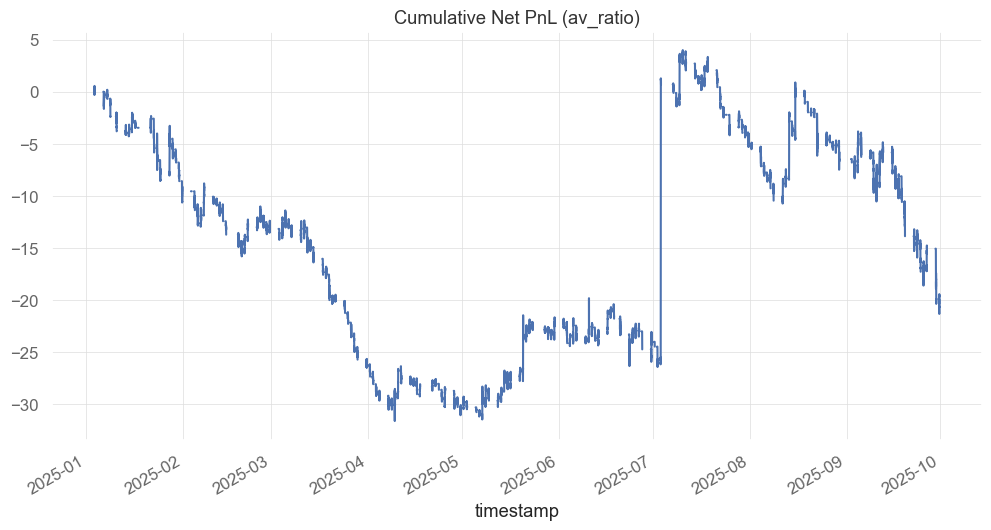

In [80]:

dataUSA_2["pnl_net_avratio"].cumsum().plot(figsize=(12,6), 
                                           title="Cumulative Net PnL (av_ratio)")
plt.show()

# Cummulative Gross PnL (sdsratio)

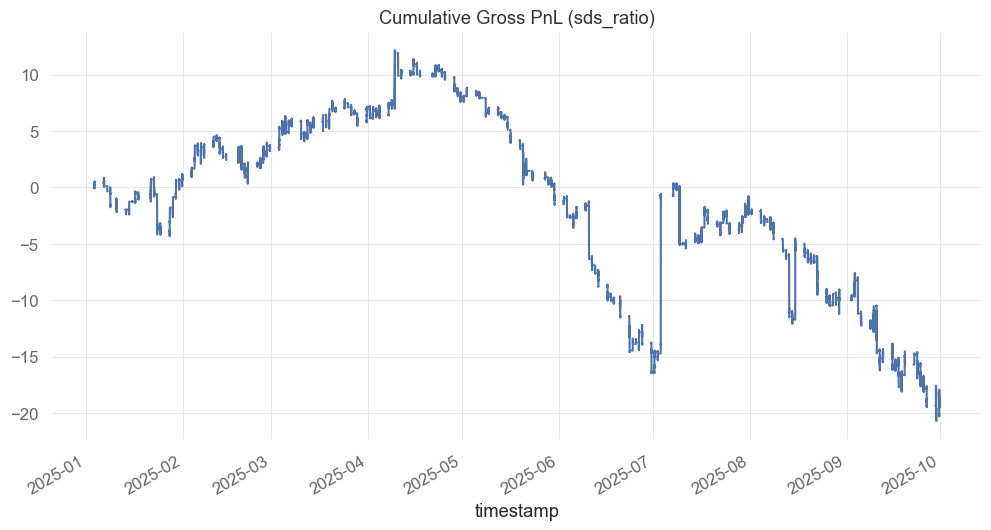

In [76]:
dataUSA_2["pnl_gross_sdsratio"] = dataUSA_2["pos_sdsratio"] * (dataUSA_2["close_GOOGL"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_MSFT"].diff())
dataUSA_2["n_trans_sdsratio"] = np.abs(np.diff(dataUSA_2["pos_sdsratio"], prepend = 0))
dataUSA_2["pnl_net_sdsratio"] = dataUSA_2["pnl_gross_sdsratio"] - dataUSA_2["n_trans_sdsratio"] * (trcost_GOOGL + dataUSA_2["av_ratio"] * trcost_MSFT)


trcost_GOOGL = round(dataUSA_close["close_GOOGL"].mean() * 0.0005, 2) #### transaction costs at 5bp
trcost_MSFT = round(dataUSA_close["close_MSFT"].mean() * 0.0005, 2)


dataUSA_2["pnl_gross_sdsratio"].cumsum().plot(figsize=(12,6), 
                                             title="Cumulative Gross PnL (sds_ratio)")
plt.show()

# Cummulative net PnL (sdsratio)

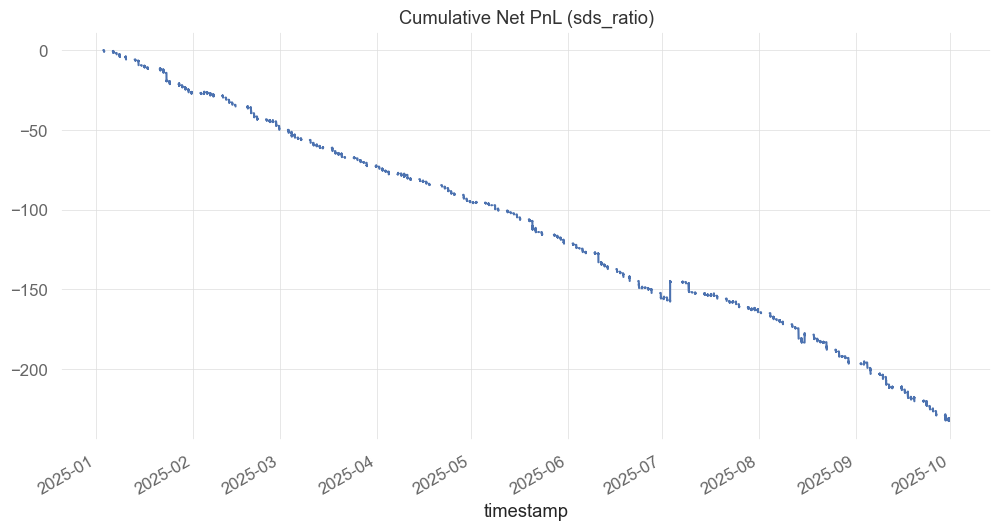

In [77]:

dataUSA_2["pnl_net_sdsratio"].cumsum().plot(figsize=(12,6), 
                                           title="Cumulative Net PnL (sds_ratio)")
plt.show()

# as expected :)